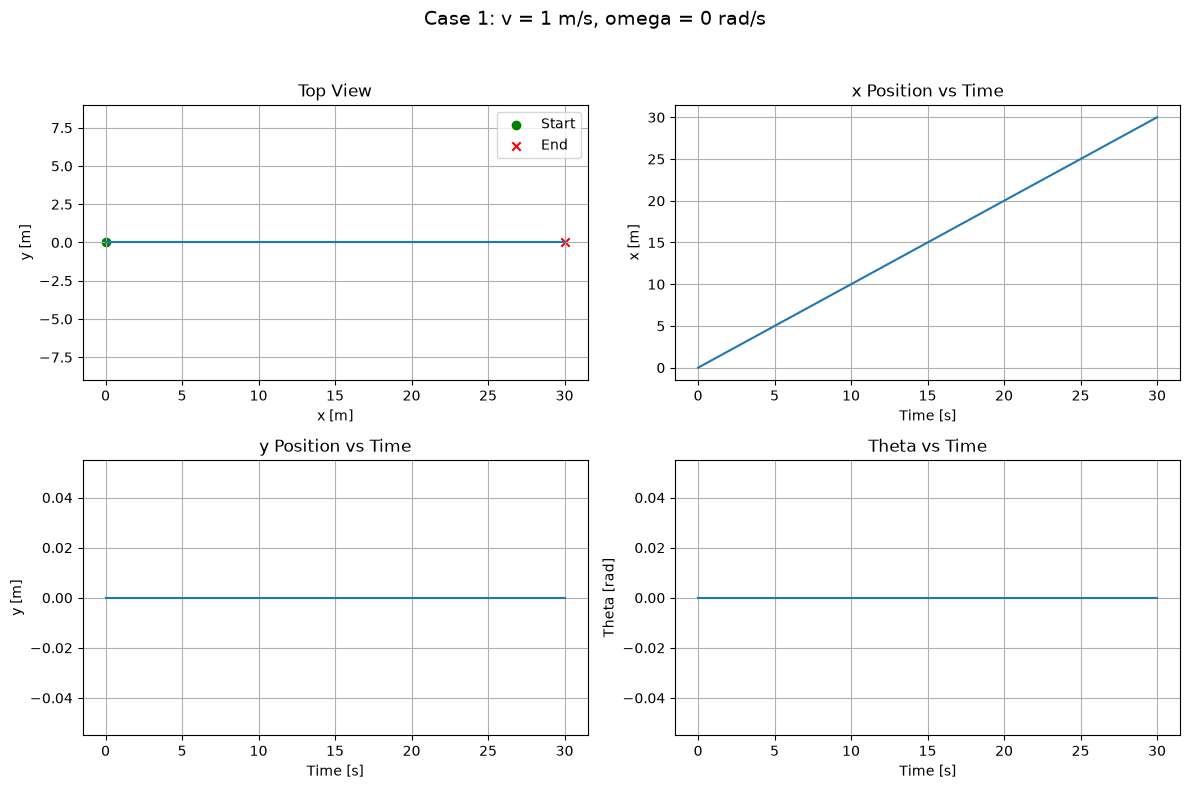

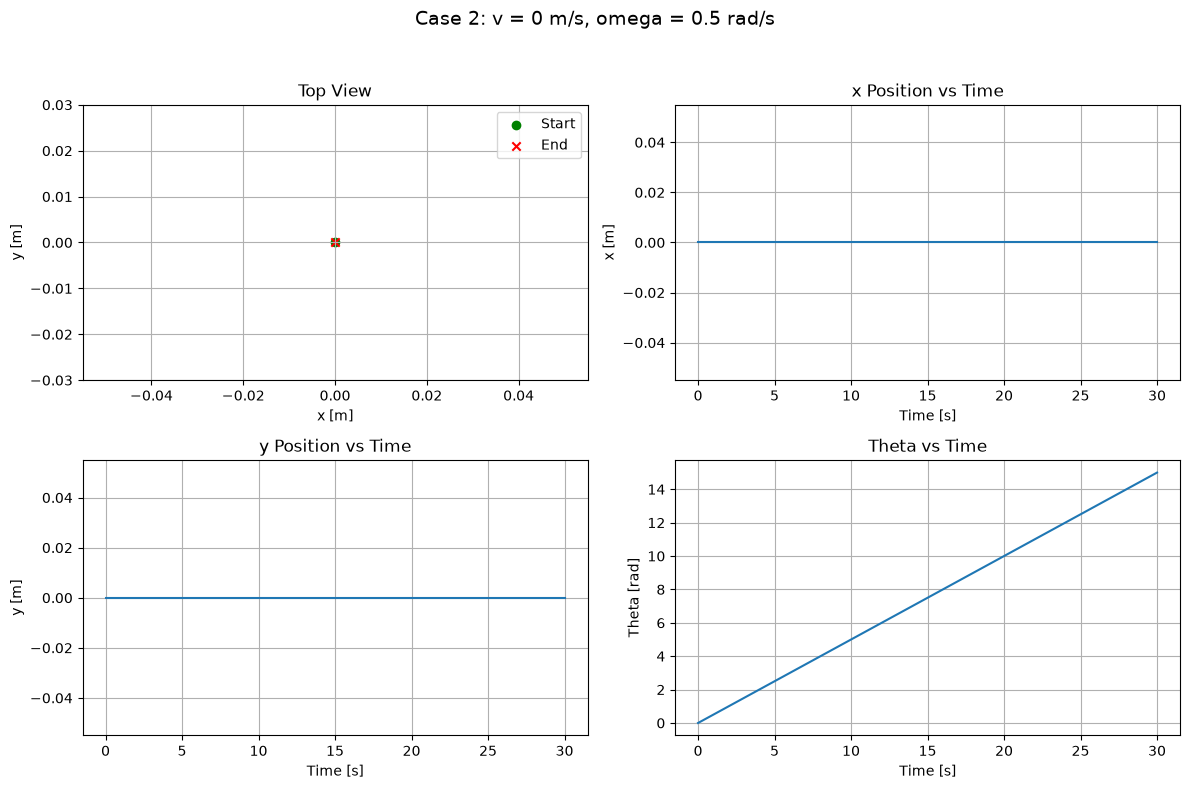

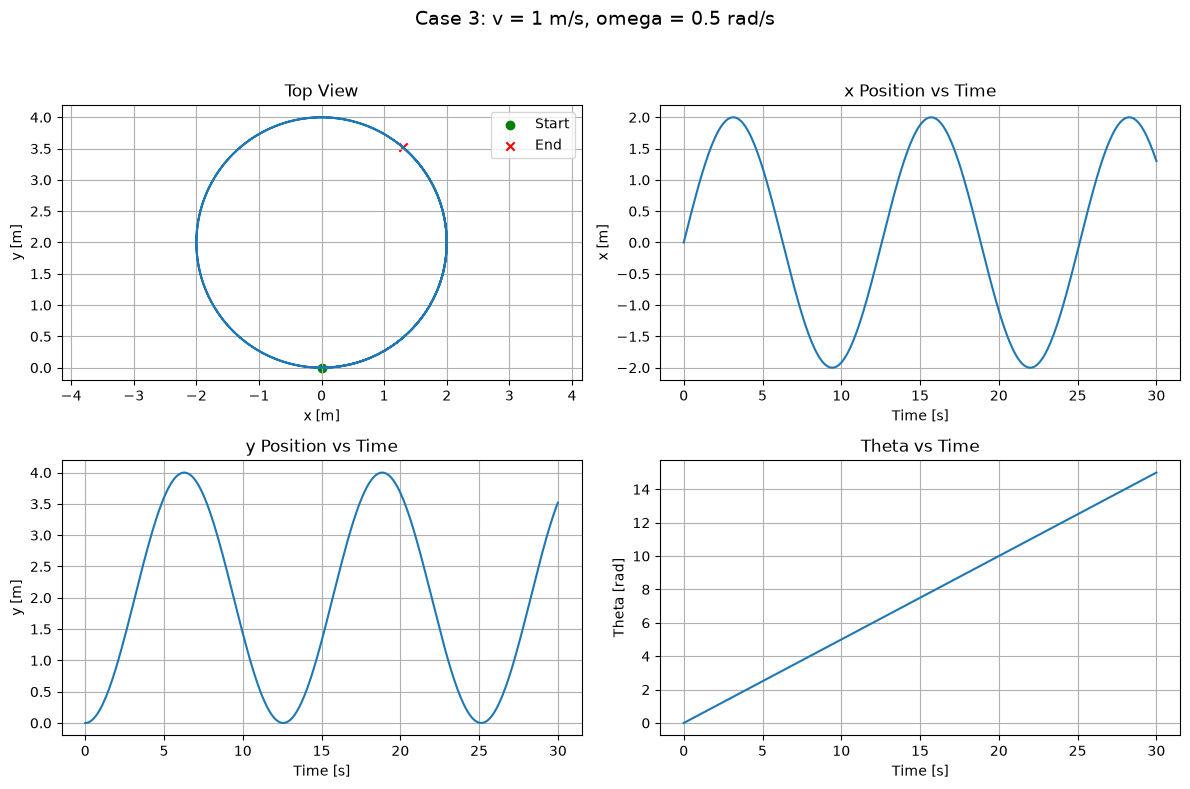

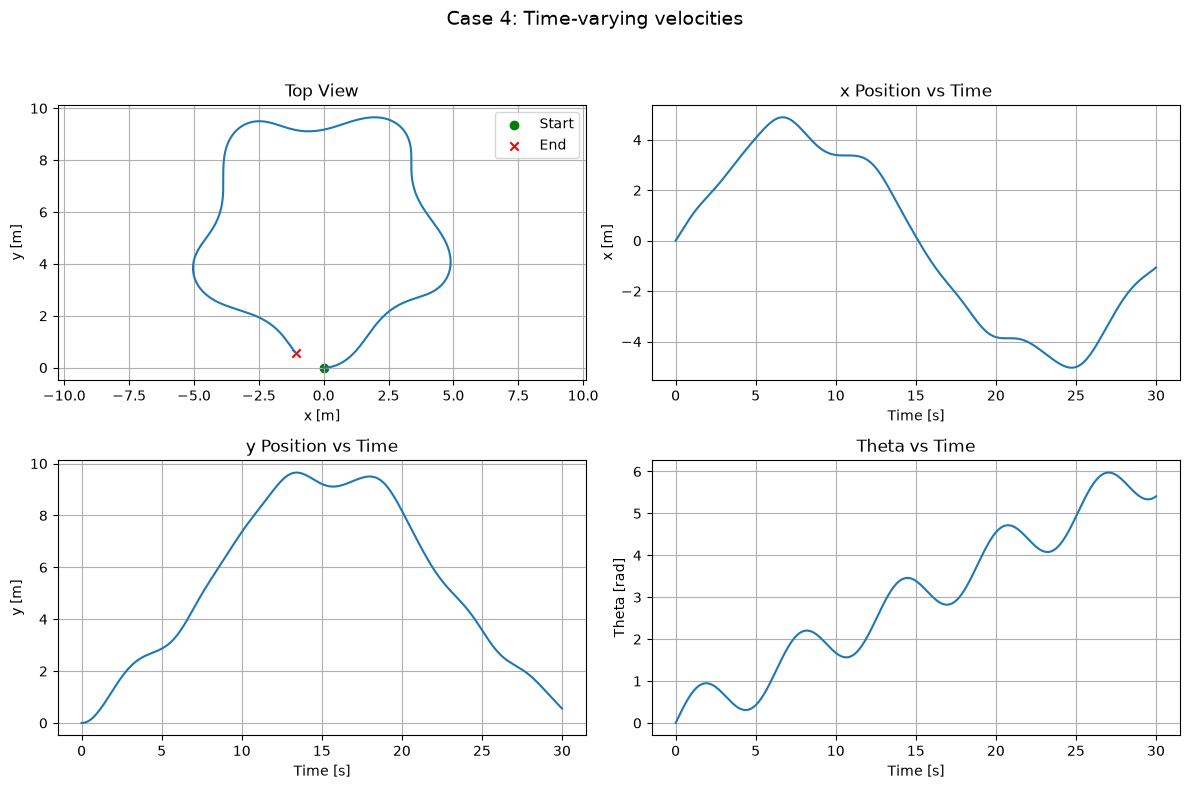

In [ ]:
# Approached this similar to the sample provided by Pi
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Start with defining each of the 4 cases
velocity_profiles = {
    "Case 1: v = 1 m/s, omega = 0 rad/s": {
        "linear": lambda t: 1.0,
        "angular": lambda t: 0.0
    },
    "Case 2: v = 0 m/s, omega = 0.5 rad/s": {
        "linear": lambda t: 0.0,
        "angular": lambda t: 0.5
    },
    "Case 3: v = 1 m/s, omega = 0.5 rad/s": {
        "linear": lambda t: 1.0,
        "angular": lambda t: 0.5
    },
    "Case 4: Time-varying velocities": {
        "linear": lambda t: 1.0 + 0.2 * np.sin(t),
        "angular": lambda t: 0.2 + 0.6 * np.cos(t)
    }
}

# Define the control law
def control_law(t, state, velocity_profile):
    v = velocity_profile["linear"](t)
    omega = velocity_profile["angular"](t)

    return v, omega

# Define the system dynamics
def system_dynamics(state, t, velocity_profile):
    x, y, theta = state # State variables

    # Calculate control input
    v, omega = control_law(t, state, velocity_profile)

    # Robot kinematics
    dxdt = v * np.cos(theta)
    dydt = v * np.sin(theta)
    dthetadt = omega

    return [dxdt, dydt, dthetadt]

# initial conditions - assumptions 
x0 = 0.0       # Initial x position [m]
y0 = 0.0       # Initial y position [m]
theta0 = 0.0   # Initial theta [rad]
initial_state = [x0, y0, theta0]

# time span for simulation
duration = 30.0 # simulating from 0 to 30 seconds
t = np.linspace(0, duration, 301)

# Store results for later use
results = {}

# Simulate each velocity profile
for case_name, velocity_profile in velocity_profiles.items():

    # Solve the ODE using odeint
    solution = odeint(
        system_dynamics,
        initial_state,
        t,
        args=(velocity_profile,)
    )

    # Get x, y, and theta
    x = solution[:, 0]
    y = solution[:, 1]
    theta = solution[:, 2]

    results[case_name] = solution

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(case_name, fontsize=14)

    # Top view
    axes[0, 0].plot(x, y)
    axes[0, 0].scatter(x[0], y[0], color="green", label="Start")
    axes[0, 0].scatter(x[-1], y[-1], color="red", marker="x", label="End")
    axes[0, 0].set(title="Top View", xlabel="x [m]", ylabel="y [m]")
    axes[0, 0].axis("equal")
    axes[0, 0].legend()

    # x versus time
    axes[0, 1].plot(t, x)
    axes[0, 1].set(title="x Position vs Time", xlabel="Time [s]", ylabel="x [m]")

    # y versus time
    axes[1, 0].plot(t, y)
    axes[1, 0].set(title="y Position vs Time", xlabel="Time [s]", ylabel="y [m]")

    # Theta versus time
    axes[1, 1].plot(t, theta)
    axes[1, 1].set(title="Theta vs Time", xlabel="Time [s]", ylabel="Theta [rad]")

    for ax in axes.flat:
        ax.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
## Part B of Question 2 

## Computed by hand in the report, simply applying the formulas for wheel speeds